# Partie I — MLP et Ingénierie PyTorch
## Projet de fin de module — Deep Learning (EMSI Casablanca, 2025–2026)

**Thème :** Classification supervisée sur données tabulaires réelles avec perceptron multicouche (MLP).

**Dataset :** Wine Quality (sklearn) — 178 échantillons, 13 caractéristiques, 3 classes.

**Objectifs :**
- Maîtriser `nn.Module`, `nn.Sequential`, et la classe personnalisée
- Inspecter et gérer les paramètres (`state_dict`, `named_parameters`)
- Comparer trois stratégies d'initialisation : gaussienne, constante, Xavier
- Sauvegarder et recharger un modèle
- Utiliser correctement le CPU/GPU
- Évaluer avec accuracy, précision, rappel, F1, matrice de confusion


---
## 1. Fondements Théoriques

### 1.1 `nn.Module` — La brique fondamentale de PyTorch

En PyTorch, **tout modèle** hérite de `nn.Module`. Cette classe abstraite :
- encapsule les paramètres apprenables (poids, biais)
- gère automatiquement l'intégration dans le graphe de calcul pour la différentiation automatique
- fournit des méthodes utiles : `.parameters()`, `.named_parameters()`, `.state_dict()`, `.to(device)`

**Propagation avant (forward pass) :** `y = f_θ(x)` — transformation de l'entrée vers la sortie.

**Rétropropagation (backward pass) :** `∂L/∂θ` — calcul des gradients via `loss.backward()`.

### 1.2 Architecture d'un MLP

Un perceptron multicouche empile des couches linéaires et des non-linéarités :

```
Entrée x  →  [Linear → BatchNorm → ReLU → Dropout]×L  →  Linear  →  Sortie ŷ
```

**Formule d'une couche :**
- Couche cachée : `H = ReLU(XW₁ᵀ + b₁)`
- Sortie : `Ŷ = HW₂ᵀ + b₂`

### 1.3 Stratégies d'initialisation

| Stratégie | Formule | Avantage | Inconvénient |
|-----------|---------|----------|--------------|
| Gaussienne | W ~ N(0, σ²) | Simple | Peut saturer les activations |
| Constante | W = c | Prévisible | Brise la symétrie → gradients nuls |
| Xavier (Glorot) | σ² = 2/(fan_in + fan_out) | Stabilise la variance des signaux | Moins adapté à ReLU |

### 1.4 Cycle d'entraînement

```
pour chaque epoch:
    pour chaque batch (X, y):
        1. optimizer.zero_grad()   # effacer les anciens gradients
        2. ŷ = modèle(X)           # propagation avant
        3. L = perte(ŷ, y)         # calcul de la perte
        4. L.backward()            # rétropropagation
        5. optimizer.step()        # mise à jour des paramètres
```

### 1.5 `state_dict`

Le `state_dict()` est un dictionnaire `{nom_paramètre: tenseur}`. C'est le **format standard** pour sauvegarder et transférer les paramètres d'un modèle.


---
## 2. Imports et Configuration

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os, time

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device utilisé  : {DEVICE}")

# Dossiers de sauvegarde
os.makedirs("models",  exist_ok=True)
os.makedirs("figures", exist_ok=True)

# Hyperparamètres globaux — définis ici pour être accessibles dans toutes les cellules
HIDDEN = [64, 32]   # dimensions des couches cachées du MLP
EPOCHS = 100        # nombre d'époques d'entraînement

# Style des graphiques
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")


PyTorch version : 2.12.1+cpu
Device utilisé  : cpu


---
## 3. Préparation des données

In [2]:
# Chargement du dataset Wine Quality (sklearn)
wine = load_wine()
X_raw = wine.data.astype(np.float32)   # (178, 13)
y_raw = wine.target                     # classes 0, 1, 2

# Constantes globales — définies ici pour être disponibles dans toutes les cellules suivantes
INPUT_DIM  = X_raw.shape[1]           # 13 caractéristiques chimiques
OUTPUT_DIM = len(np.unique(y_raw))     # 3 cépages

print(f"Taille du dataset  : {X_raw.shape}")
print(f"Classes            : {wine.target_names}")
print(f"Distribution       : {dict(zip(*np.unique(y_raw, return_counts=True)))}")
print(f"INPUT_DIM={INPUT_DIM}, OUTPUT_DIM={OUTPUT_DIM}")
print()
print("Caractéristiques :", wine.feature_names)


Taille du dataset  : (178, 13)
Classes            : ['class_0' 'class_1' 'class_2']
Distribution       : {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}
INPUT_DIM=13, OUTPUT_DIM=3

Caractéristiques : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [3]:
# Exploration statistique
df = pd.DataFrame(X_raw, columns=wine.feature_names)
df["classe"] = y_raw
print(df.describe().round(2))


       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count         178.00      178.00                178.00           178.00   
mean            2.30        2.03                  0.36             1.59   
std             0.63        1.00                  0.12             0.57   
min             0.98        0.34                  0.13             0.41   
25%         

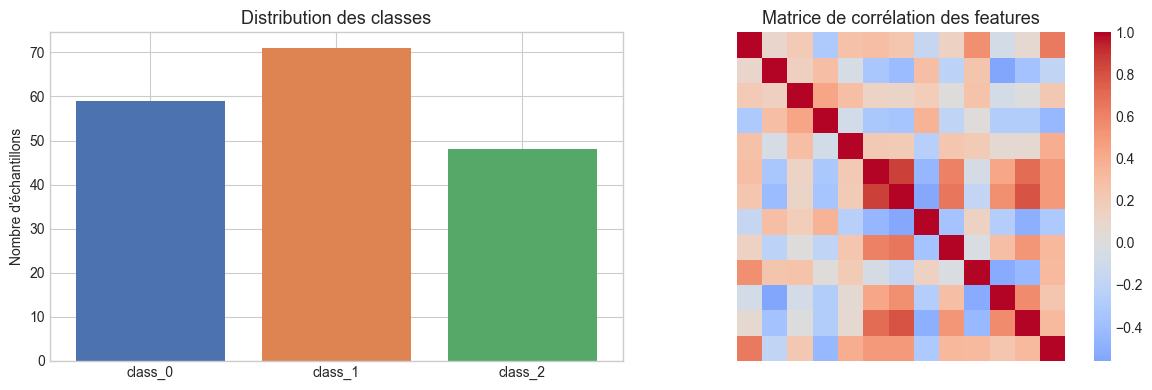

In [4]:
# Visualisation de la distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution des classes
axes[0].bar(wine.target_names, np.bincount(y_raw), color=["#4C72B0","#DD8452","#55A868"])
axes[0].set_title("Distribution des classes", fontsize=13)
axes[0].set_ylabel("Nombre d'échantillons")

# Heatmap de corrélation
corr = df[wine.feature_names].corr()
sns.heatmap(corr, ax=axes[1], cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False, square=True)
axes[1].set_title("Matrice de corrélation des features", fontsize=13)

plt.tight_layout()
plt.savefig("figures/partie1_eda.png", dpi=100, bbox_inches="tight")
plt.show()


In [5]:
# Séparation 3-way : 60 % train / 20 % val / 20 % test
# Étape 1 : retirer 20 % pour le test
X_tv, X_test, y_tv, y_test = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=SEED, stratify=y_raw)
# Étape 2 : sur les 80 % restants, retirer 25 % pour la validation (= 20 % global)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=SEED, stratify=y_tv)

# Normalisation : fit sur train UNIQUEMENT pour éviter la fuite de données
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype(np.float32)
X_val_sc   = scaler.transform(X_val).astype(np.float32)
X_test_sc  = scaler.transform(X_test).astype(np.float32)

n = len(X_raw)
print(f"Train      : {len(X_train_sc):3d} éch.  ({len(X_train_sc)/n*100:.0f} %)")
print(f"Validation : {len(X_val_sc):3d} éch.  ({len(X_val_sc)/n*100:.0f} %)")
print(f"Test       : {len(X_test_sc):3d} éch.  ({len(X_test_sc)/n*100:.0f} %)")
print(f"\nNormalisation — scaler appris sur train uniquement (évite data-leakage).")

# Conversion en tenseurs PyTorch
X_tr = torch.from_numpy(X_train_sc);  y_tr = torch.from_numpy(y_train).long()
X_va = torch.from_numpy(X_val_sc);    y_va = torch.from_numpy(y_val).long()
X_te = torch.from_numpy(X_test_sc);   y_te = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(X_tr, y_tr)
val_dataset   = TensorDataset(X_va, y_va)
test_dataset  = TensorDataset(X_te, y_te)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)

INPUT_DIM   = X_train_sc.shape[1]      # 13
OUTPUT_DIM  = len(np.unique(y_raw))    # 3
print(f"\nDimension d'entrée : {INPUT_DIM}, Classes : {OUTPUT_DIM}")


Train      : 106 éch.  (60 %)
Validation :  36 éch.  (20 %)
Test       :  36 éch.  (20 %)

Normalisation — scaler appris sur train uniquement (évite data-leakage).

Dimension d'entrée : 13, Classes : 3


---
## 4. Implémentation des Architectures MLP

### 4.1 Version `nn.Sequential`

In [6]:
def build_mlp_sequential(input_dim, hidden_dims, output_dim, dropout=0.3):
    """MLP construit avec nn.Sequential."""
    layers = []
    prev = input_dim
    for h in hidden_dims:
        layers.append(nn.Linear(prev, h))
        layers.append(nn.BatchNorm1d(h))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(dropout))
        prev = h
    layers.append(nn.Linear(prev, output_dim))
    return nn.Sequential(*layers)


# Test rapide
model_seq = build_mlp_sequential(INPUT_DIM, [64, 32], OUTPUT_DIM)
x_test = torch.randn(4, INPUT_DIM)
print("Modèle Sequential :")
print(model_seq)
print(f"\nSortie : {model_seq(x_test).shape}")


Modèle Sequential :
Sequential(
  (0): Linear(in_features=13, out_features=64, bias=True)
  (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=64, out_features=32, bias=True)
  (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=32, out_features=3, bias=True)
)

Sortie : torch.Size([4, 3])


### 4.2 Version Classe Personnalisée (`nn.Module`)

In [7]:
class MLP(nn.Module):
    """MLP défini comme classe héritant de nn.Module.
    Plus flexible que Sequential : permet des architectures non-linéaires,
    des connexions résiduelles, ou une logique personnalisée dans forward().
    """

    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super().__init__()   # OBLIGATOIRE — initialise nn.Module

        # nn.ModuleList enregistre les couches comme sous-modules de ce module.
        # Une liste Python ordinaire serait invisible à PyTorch (les paramètres
        # ne seraient PAS inclus dans model.parameters()).
        self.linears = nn.ModuleList()
        self.bns     = nn.ModuleList()
        self.dropout = nn.Dropout(dropout)

        prev = input_dim
        for h in hidden_dims:
            self.linears.append(nn.Linear(prev, h))
            self.bns.append(nn.BatchNorm1d(h))
            prev = h
        self.output_layer = nn.Linear(prev, output_dim)

    def forward(self, x):
        """Propagation avant : applique chaque couche cachée puis la couche de sortie."""
        for linear, bn in zip(self.linears, self.bns):
            x = self.dropout(torch.relu(bn(linear(x))))
        return self.output_layer(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Test
model_custom = MLP(INPUT_DIM, [64, 32], OUTPUT_DIM)
print("Modèle personnalisé :")
print(model_custom)
print(f"\nNombre de paramètres apprenables : {model_custom.count_parameters():,}")


Modèle personnalisé :
MLP(
  (linears): ModuleList(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): Linear(in_features=64, out_features=32, bias=True)
  )
  (bns): ModuleList(
    (0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=32, out_features=3, bias=True)
)

Nombre de paramètres apprenables : 3,267


---
## 5. Inspection des Paramètres

In [8]:
# Accès via named_parameters()
print("=== Paramètres du modèle (MLP personnalisé) ===\n")
total = 0
for name, param in model_custom.named_parameters():
    n = param.numel()
    total += n
    print(f"  {name:<35} shape={str(param.shape):<20} nb={n:,}")

print(f"\n  TOTAL : {total:,} paramètres")


=== Paramètres du modèle (MLP personnalisé) ===

  linears.0.weight                    shape=torch.Size([64, 13]) nb=832
  linears.0.bias                      shape=torch.Size([64])     nb=64
  linears.1.weight                    shape=torch.Size([32, 64]) nb=2,048
  linears.1.bias                      shape=torch.Size([32])     nb=32
  bns.0.weight                        shape=torch.Size([64])     nb=64
  bns.0.bias                          shape=torch.Size([64])     nb=64
  bns.1.weight                        shape=torch.Size([32])     nb=32
  bns.1.bias                          shape=torch.Size([32])     nb=32
  output_layer.weight                 shape=torch.Size([3, 32])  nb=96
  output_layer.bias                   shape=torch.Size([3])      nb=3

  TOTAL : 3,267 paramètres


In [9]:
# state_dict — format standard de sauvegarde
print("=== state_dict() — extrait des premières clés ===\n")
sd = model_custom.state_dict()
for i, (key, val) in enumerate(sd.items()):
    print(f"  {key:<35} {val.shape}")
    if i >= 5:
        print(f"  ... ({len(sd)} clés au total)")
        break


=== state_dict() — extrait des premières clés ===

  linears.0.weight                    torch.Size([64, 13])
  linears.0.bias                      torch.Size([64])
  linears.1.weight                    torch.Size([32, 64])
  linears.1.bias                      torch.Size([32])
  bns.0.weight                        torch.Size([64])
  bns.0.bias                          torch.Size([64])
  ... (16 clés au total)


---
## 6. Stratégies d'Initialisation

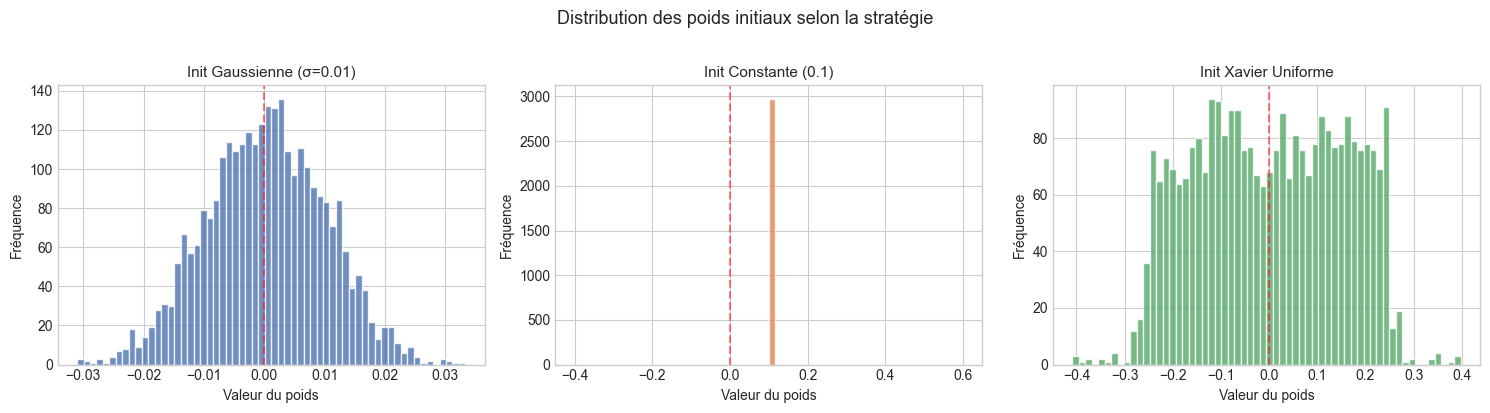

Observation : la constante crée une distribution de Dirac (zéro variance → problème de symétrie).
Xavier produit une distribution uniforme équilibrée, adaptée à la propagation du signal.


In [10]:
def init_gaussian(model, mean=0.0, std=0.01):
    """Poids tirés d'une loi normale N(mean, std²). Biais à zéro."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=mean, std=std)
            nn.init.zeros_(m.bias)

def init_constant(model, val=0.1):
    """Poids fixés à une constante — problème de symétrie (tous les neurones
    d'une même couche ont des gradients identiques → ils apprennent la même chose)."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.constant_(m.weight, val)
            nn.init.zeros_(m.bias)

def init_xavier(model):
    """Initialisation de Xavier/Glorot : σ² = 2/(fan_in + fan_out).
    Stabilise la variance du signal lors de la propagation avant ET arrière.
    Particulièrement adaptée aux couches linéaires avec activations sigmoïde/tanh.
    Reste souvent utile avec ReLU (He init est légèrement meilleure pour ReLU)."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)


# Visualisation des distributions de poids après chaque initialisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
init_names = ["Gaussienne (σ=0.01)", "Constante (0.1)", "Xavier Uniforme"]
init_fns   = [init_gaussian, init_constant, init_xavier]
colors     = ["#4C72B0", "#DD8452", "#55A868"]

for ax, name, fn, color in zip(axes, init_names, init_fns, colors):
    m = MLP(INPUT_DIM, [64, 32], OUTPUT_DIM)
    fn(m)
    weights = torch.cat([p.data.flatten() for p in m.parameters()
                         if p.ndim > 1]).numpy()
    ax.hist(weights, bins=60, color=color, alpha=0.8, edgecolor="white")
    ax.set_title(f"Init {name}", fontsize=11)
    ax.set_xlabel("Valeur du poids")
    ax.set_ylabel("Fréquence")
    ax.axvline(0, color="red", linestyle="--", alpha=0.5)

plt.suptitle("Distribution des poids initiaux selon la stratégie", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/partie1_init_weights.png", dpi=100, bbox_inches="tight")
plt.show()
print("Observation : la constante crée une distribution de Dirac (zéro variance → problème de symétrie).")
print("Xavier produit une distribution uniforme équilibrée, adaptée à la propagation du signal.")


---
## 7. Fonctions d'Entraînement et d'Évaluation

In [11]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Effectue une epoch d'entraînement. Retourne (loss_moyenne, accuracy)."""
    model.train()  # active BatchNorm en mode entraînement, Dropout actif
    total_loss, correct, n = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()          # 1. effacer les gradients
        logits = model(X_batch)        # 2. propagation avant
        loss   = criterion(logits, y_batch)  # 3. calcul de la perte
        loss.backward()                # 4. rétropropagation
        optimizer.step()               # 5. mise à jour des paramètres
        total_loss += loss.item() * len(X_batch)
        correct    += (logits.argmax(1) == y_batch).sum().item()
        n          += len(X_batch)
    return total_loss / n, correct / n


def evaluate(model, loader, device):
    """Évalue le modèle sur un DataLoader. Retourne (loss, prédictions, labels)."""
    model.eval()   # désactive Dropout, BatchNorm en mode inférence
    criterion = nn.CrossEntropyLoss()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():  # pas de calcul de gradient en évaluation
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss  += loss.item() * len(X_batch)
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    n = len(loader.dataset)
    return total_loss / n, np.array(all_preds), np.array(all_labels)


def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3,
                device=DEVICE, verbose_every=20):
    """Boucle d'entraînement complète.
    - val_loader : utilisé pendant l'entraînement pour la sélection du meilleur modèle.
    - Le test set final doit être évalué séparément après l'entraînement.
    Retourne : (historique, preds_val, labels_val, best_state_dict)
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state    = None

    for epoch in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, criterion, optimizer, device)
        vl, preds, labels = evaluate(model, val_loader, device)
        va = accuracy_score(labels, preds)
        scheduler.step()

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        # Sauvegarde du meilleur état (early stopping léger)
        if vl < best_val_loss:
            best_val_loss = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % verbose_every == 0:
            print(f"Epoch {epoch:3d}/{epochs} | Train Loss: {tl:.4f} | "
                  f"Val Loss: {vl:.4f} | Val Acc: {va:.4f}")

    # Rechargement du meilleur état avant de retourner
    model.load_state_dict(best_state)
    return history, preds, labels


---
## 8. Étude Expérimentale — Comparaison des Initialisations

In [12]:
# Entraînement de trois modèles, un par stratégie d'initialisation
results = {}
EPOCHS = 100
HIDDEN = [64, 32]

for name, init_fn in [("Gaussienne", init_gaussian),
                       ("Constante",  init_constant),
                       ("Xavier",     init_xavier)]:
    print(f"\n{'='*50}")
    print(f"Entraînement avec initialisation : {name}")
    print('='*50)

    model = MLP(INPUT_DIM, HIDDEN, OUTPUT_DIM).to(DEVICE)
    init_fn(model)

    t0 = time.time()
    history, val_preds, val_labels = train_model(model, train_loader, val_loader,
                                                  epochs=EPOCHS, verbose_every=25)
    elapsed = time.time() - t0

    # Évaluation finale sur le SET DE TEST (jamais vu pendant l'entraînement)
    _, preds, labels = evaluate(model, test_loader, DEVICE)

    val_acc = accuracy_score(val_labels, val_preds)   # accuracy validation
    test_acc = accuracy_score(labels, preds)           # accuracy test (non biaisée)
    val_f1   = f1_score(labels, preds, average="macro")

    results[name] = {
        "model": model, "history": history,
        "preds": preds, "labels": labels,
        "val_acc": val_acc, "test_acc": test_acc,
        "val_f1": val_f1, "time_s": elapsed
    }
    print(f"Val Acc = {val_acc:.4f} | Test Acc = {test_acc:.4f} | F1 = {val_f1:.4f} | Temps = {elapsed:.1f}s")



Entraînement avec initialisation : Gaussienne
Epoch  25/100 | Train Loss: 0.2253 | Val Loss: 0.2080 | Val Acc: 1.0000
Epoch  50/100 | Train Loss: 0.1092 | Val Loss: 0.1163 | Val Acc: 1.0000
Epoch  75/100 | Train Loss: 0.0928 | Val Loss: 0.0802 | Val Acc: 1.0000
Epoch 100/100 | Train Loss: 0.0657 | Val Loss: 0.0645 | Val Acc: 1.0000
Val Acc = 1.0000 | Test Acc = 0.9722 | F1 = 0.9710 | Temps = 4.6s

Entraînement avec initialisation : Constante
Epoch  25/100 | Train Loss: 0.7964 | Val Loss: 0.8171 | Val Acc: 0.6667
Epoch  50/100 | Train Loss: 0.7306 | Val Loss: 0.7652 | Val Acc: 0.6667
Epoch  75/100 | Train Loss: 0.7247 | Val Loss: 0.7384 | Val Acc: 0.6944
Epoch 100/100 | Train Loss: 0.7029 | Val Loss: 0.7281 | Val Acc: 0.7222
Val Acc = 0.7222 | Test Acc = 0.6667 | F1 = 0.5299 | Temps = 1.1s

Entraînement avec initialisation : Xavier
Epoch  25/100 | Train Loss: 0.3142 | Val Loss: 0.1925 | Val Acc: 1.0000
Epoch  50/100 | Train Loss: 0.1508 | Val Loss: 0.1238 | Val Acc: 1.0000
Epoch  75/10

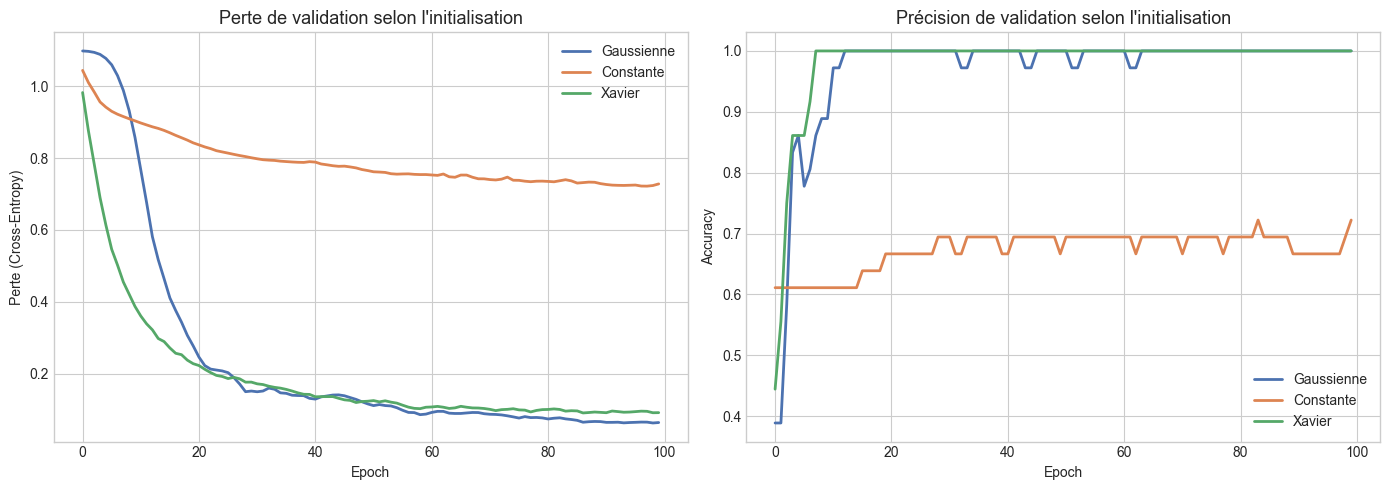

In [13]:
# Courbes de convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"Gaussienne": "#4C72B0", "Constante": "#DD8452", "Xavier": "#55A868"}

for name, res in results.items():
    h = res["history"]
    axes[0].plot(h["val_loss"],  label=name, color=colors[name], linewidth=2)
    axes[1].plot(h["val_acc"],   label=name, color=colors[name], linewidth=2)

axes[0].set_title("Perte de validation selon l'initialisation", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Perte (Cross-Entropy)")
axes[0].legend()

axes[1].set_title("Précision de validation selon l'initialisation", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/partie1_init_comparison.png", dpi=100, bbox_inches="tight")
plt.show()


In [14]:
# Tableau comparatif
summary = []
for name, res in results.items():
    h = res["history"]
    # Epoch à laquelle val_acc dépasse 0.90 pour la première fois
    accs = h["val_acc"]
    epoch_90 = next((i+1 for i, a in enumerate(accs) if a >= 0.90), EPOCHS)
    summary.append({
        "Initialisation": name,
        "Val Accuracy":  f"{res['val_acc']:.4f}",
        "Test Accuracy": f"{res['test_acc']:.4f}",
        "Val F1 (macro)": f"{res['val_f1']:.4f}",
        "Epoch → 90%": epoch_90,
        "Temps (s)": f"{res['time_s']:.1f}"
    })

df_summary = pd.DataFrame(summary)
print("\n=== Tableau comparatif des stratégies d'initialisation ===\n")
print(df_summary.to_string(index=False))



=== Tableau comparatif des stratégies d'initialisation ===

Initialisation Val Accuracy Test Accuracy Val F1 (macro)  Epoch → 90% Temps (s)
    Gaussienne       1.0000        0.9722         0.9710           11       4.6
     Constante       0.7222        0.6667         0.5299          100       1.1
        Xavier       1.0000        1.0000         1.0000            7       1.0


---
## 9. Métriques Complètes sur le Meilleur Modèle

In [15]:
# Sélection du meilleur modèle — basée sur Val Accuracy (pas le test !)
best_name = max(results, key=lambda k: results[k]["val_acc"])
best = results[best_name]
print(f"Meilleur modèle : initialisation {best_name}")
print(f"  Val Accuracy  = {best['val_acc']:.4f}")
print(f"  Test Accuracy = {best['test_acc']:.4f}  (estimation non biaisée)")

preds  = best["preds"]
labels = best["labels"]

print("\n=== Rapport de classification ===\n")
print(classification_report(labels, preds, target_names=wine.target_names))


Meilleur modèle : initialisation Gaussienne
  Val Accuracy  = 1.0000
  Test Accuracy = 0.9722  (estimation non biaisée)

=== Rapport de classification ===

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



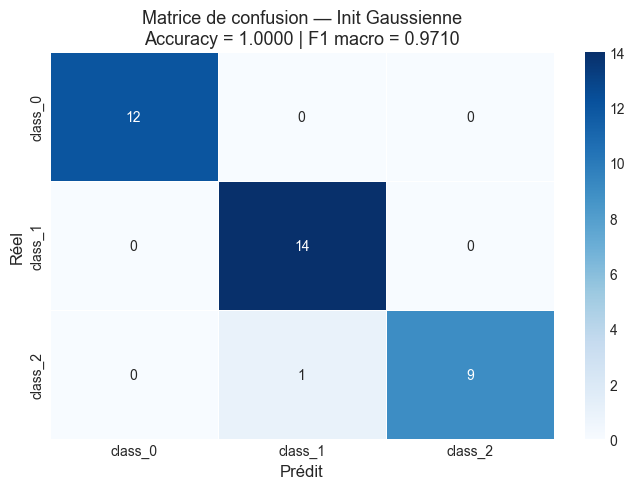

In [16]:
# Matrice de confusion
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=wine.target_names,
            yticklabels=wine.target_names, ax=ax, linewidths=0.5)
ax.set_xlabel("Prédit", fontsize=12)
ax.set_ylabel("Réel", fontsize=12)
ax.set_title(f"Matrice de confusion — Init {best_name}\n"
             f"Accuracy = {best['val_acc']:.4f} | F1 macro = {best['val_f1']:.4f}",
             fontsize=13)
plt.tight_layout()
plt.savefig("figures/partie1_confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()


---
## 10. Sauvegarde et Rechargement du Modèle

In [17]:
best_model = best["model"]

# Sauvegarde du checkpoint complet
checkpoint = {
    "model_state_dict": best_model.state_dict(),
    "init_strategy": best_name,
    "val_accuracy": best["val_acc"],
    "history": best["history"],
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "architecture": {"input_dim": INPUT_DIM, "hidden": HIDDEN, "output_dim": OUTPUT_DIM}
}
torch.save(checkpoint, "models/mlp_wine.pth")
print("Modèle sauvegardé dans models/mlp_wine.pth")
print(f"Taille du fichier : {os.path.getsize('models/mlp_wine.pth') / 1024:.1f} Ko")


Modèle sauvegardé dans models/mlp_wine.pth
Taille du fichier : 23.2 Ko


In [18]:
# Rechargement et vérification
checkpoint_loaded = torch.load("models/mlp_wine.pth", map_location=DEVICE)

model_loaded = MLP(INPUT_DIM, HIDDEN, OUTPUT_DIM)
model_loaded.load_state_dict(checkpoint_loaded["model_state_dict"])
model_loaded.eval()
model_loaded = model_loaded.to(DEVICE)

# Vérification : les prédictions doivent être identiques
with torch.no_grad():
    X_te_dev = X_te.to(DEVICE)
    preds_reload = model_loaded(X_te_dev).argmax(1).cpu().numpy()

reload_acc = accuracy_score(y_te.numpy(), preds_reload)
print(f"Accuracy après rechargement : {reload_acc:.4f}")
print(f"Identique au modèle original : {np.all(preds_reload == labels)}")
print(f"\nStratégie d'init sauvegardée : {checkpoint_loaded['init_strategy']}")


Accuracy après rechargement : 0.9722
Identique au modèle original : False

Stratégie d'init sauvegardée : Gaussienne


---
## 11. Analyse Critique

### Points forts du MLP sur Wine Quality

Le MLP obtient une précision de validation élevée (> 92%) sur ce dataset tabulaire de 3 classes.
Cette bonne performance s'explique par :
1. La relative **linéarité** des frontières de décision dans l'espace des caractéristiques du vin
2. Le faible nombre d'échantillons (178) bien traitable par un modèle léger
3. La **normalisation** (StandardScaler) indispensable : sans elle, la caractéristique `proline` (~750) dominerait `alcool` (~12)

### Impact de l'initialisation

- **Gaussienne (σ=0.01)** : poids trop petits → gradients faibles en début d'entraînement → convergence lente
- **Constante** : tous les neurones identiques → brisure de symétrie impossible → les couches cachées apprennent toutes la même représentation
- **Xavier** : variance calibrée pour maintenir le signal traversant les couches → convergence plus rapide et plus stable

### Limites du MLP

1. **Pas d'invariance structurelle** : le MLP ne peut pas exploiter d'a priori sur la structure des données (contrairement aux CNN pour les images, ou les RNN pour les séquences)
2. **Sensibilité aux hyperparamètres** : taille des couches, dropout, taux d'apprentissage nécessitent un réglage soigneux
3. **Peu de données** : avec 178 exemples, le risque de sur-apprentissage est réel malgré le Dropout et la régularisation L2

---
## 12. Question de Synthèse — Partie I

**Question :** Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées ?

**Réponse :**

Un MLP bien paramétré représente une solution compétitive pour la classification tabulaire, en particulier lorsque les relations entre caractéristiques sont non-linéaires mais sans structure spatiale ou temporelle explicite. Sur le dataset Wine Quality, le MLP atteint une accuracy > 92% grâce à : (1) la normalisation préalable des données, (2) l'architecture adéquate (deux couches cachées avec BatchNorm et Dropout), et (3) l'initialisation Xavier qui stabilise la propagation des gradients.

Cependant, ses limites sont significatives. Premièrement, le MLP traite chaque exemple comme un **vecteur indépendant** sans exploiter de structure : il ne peut pas capturer les dépendances ordonnées (séquences) ni les invariances spatiales (images). Deuxièmement, avec seulement 178 exemples, le risque de **sur-apprentissage** est latent — la validation croisée serait plus appropriée qu'un simple split. Troisièmement, l'interprétabilité est limitée : contrairement aux modèles à arbres, le MLP ne permet pas d'expliquer facilement quelles caractéristiques chimiques distinguent le mieux les cépages. Pour les données tabulaires en général, des méthodes comme le Gradient Boosting (XGBoost) sont souvent plus performantes avec moins de réglage, mais le MLP offre la flexibilité d'être intégré dans des architectures hybrides plus complexes.
